# K Means Clustering with Python

K Means is an unsupervised learning algorithm used to partition data into *K* distinct clusters based on feature similarity. The goal is to minimize the variance within each cluster.

### How K Means Works:
1. **Initialization**: Randomly choose *K* initial centroids.
2. **Assignment**: Assign each data point to the nearest centroid based on distance (usually Euclidean).
3. **Update**: Calculate the new centroid of each cluster by averaging the points assigned to it.
4. **Repeat** steps 2 and 3 until the centroids no longer change significantly or a maximum number of iterations is reached.

This iterative process results in clusters of points that are more similar to each other than to points in other clusters.

---

<div style="text-align: center;">
  <a href="https://colab.research.google.com/github/MinooSdpr/Machine-Learning-101/blob/main/Session%2015/Session%2015_1%20-%20K%20Means%20Clustering.ipynb">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" />
  </a>
  &nbsp;
  <a href="https://github.com/MinooSdpr/Machine-Learning-101/blob/main/Session%2015/Session%2015_1%20-%20K%20Means%20Clustering.ipynb">
    <img src="https://img.shields.io/badge/Open%20in-GitHub-24292e?logo=github&logoColor=white" alt="Open In GitHub" />
  </a>
</div>

## Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

## Generating Sample Data with `make_blobs`

To demonstrate K Means clustering, we need some data. The `make_blobs` function from `sklearn.datasets` helps generate synthetic datasets that are ideal for clustering. It creates a specified number of clusters by generating points centered around defined centers with some spread (standard deviation).

This makes it easy to create well-separated clusters for testing clustering algorithms.

### Parameters of `make_blobs`

| Parameter         | Type               | Description                                                                                     | Default         |
|-------------------|--------------------|-------------------------------------------------------------------------------------------------|-----------------|
| `n_samples`       | int or array-like  | Total number of points to generate, or number of samples per cluster if array-like               | 100             |
| `n_features`      | int                | Number of features for each sample (dimensionality)                                            | 2               |
| `centers`         | int, array-like, or None | Number of centers to generate, or fixed center locations                                       | 3               |
| `cluster_std`     | float or array-like | Standard deviation of clusters (spread)                                                        | 1.0             |
| `center_box`      | tuple (min, max)   | Bounding box for each cluster center when centers are generated randomly                         | (-10.0, 10.0)   |
| `shuffle`         | bool               | Whether to shuffle the samples after generation                                                 | True            |
| `random_state`    | int or None        | Determines random number generation for reproducibility                                        | None            |

*Note*: You can customize these parameters to create datasets with different cluster shapes, sizes, and distributions.


In [2]:
data = make_blobs(n_samples=200, n_features=2, centers=4, cluster_std=1.8,random_state=42)

## Visualize Data

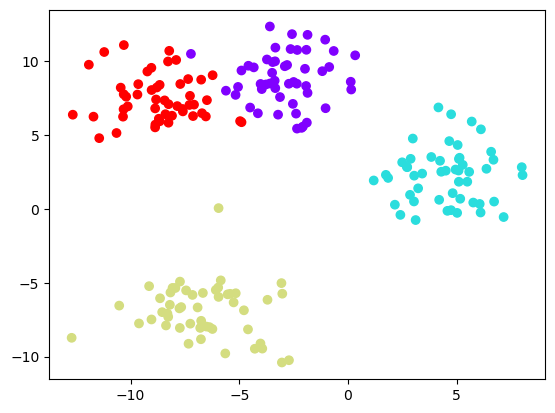

In [3]:
plt.scatter(data[0][:,0],data[0][:,1],c=data[1],cmap='rainbow')

## Creating the Clusters

| Parameter              | Type                      | Description                                                                                             | Default           |
|------------------------|---------------------------|---------------------------------------------------------------------------------------------------------|-------------------|
| `n_clusters`           | int                       | The number of clusters to form.                                                                         | 8                 |
| `init`                 | {'k-means++', 'random'} or ndarray | Method for initialization of centroids. `'k-means++'` improves convergence.                            | 'k-means++'       |
| `n_init`              | int or 'auto'             | Number of times the algorithm will run with different centroid seeds. `'auto'` chooses automatically.  | 'auto' (1.4+)     |
| `max_iter`             | int                       | Maximum number of iterations of the k-means algorithm for a single run.                                 | 300               |
| `tol`                  | float                     | Tolerance for convergence. If the change in inertia is less than `tol`, the algorithm stops.            | 1e-4              |
| `verbose`              | int                       | Verbosity mode. Set to >0 to print progress messages.                                                   | 0                 |
| `random_state`         | int, RandomState or None  | Determines random number generation for centroid initialization. Use an int for reproducibility.        | None              |
| `copy_x`               | bool                      | If True, makes a copy of the input data. If False, data may be overwritten.                            | True              |
| `algorithm`            | {'lloyd', 'elkan'}        | K-means algorithm to use. `'elkan'` is faster but only works with Euclidean distances.                 | 'lloyd'           |


In [4]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
pred = kmeans.fit_predict(data[0])

C:\Users\PC-GAM\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\PC-GAM\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\PC-GAM\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\PC-GAM\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\PC-GAM\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.Crea

In [5]:
kmeans.cluster_centers_

array([[ 4.5394351 ,  2.27912418],
       [-8.80180093,  7.6007331 ],
       [-6.65349084, -6.89692005],
       [-2.85095191,  8.66676102]])

In [6]:
kmeans.labels_

array([0, 1, 1, 1, 2, 2, 0, 1, 0, 2, 2, 0, 0, 2, 2, 2, 3, 1, 2, 2, 2, 2,
       1, 3, 1, 3, 3, 2, 3, 0, 2, 2, 1, 1, 3, 0, 1, 0, 1, 3, 2, 3, 2, 2,
       1, 0, 0, 2, 0, 3, 3, 3, 1, 0, 3, 3, 2, 2, 3, 0, 1, 0, 2, 1, 1, 2,
       0, 3, 1, 3, 3, 1, 3, 2, 0, 2, 0, 3, 2, 3, 3, 0, 2, 1, 1, 1, 1, 3,
       0, 1, 2, 3, 0, 0, 0, 1, 3, 0, 2, 3, 1, 1, 3, 2, 3, 0, 1, 2, 2, 1,
       0, 2, 3, 1, 3, 1, 1, 3, 3, 3, 3, 2, 0, 1, 1, 0, 3, 0, 0, 3, 2, 2,
       3, 1, 1, 0, 2, 2, 3, 2, 0, 3, 1, 0, 0, 3, 0, 1, 2, 2, 3, 1, 0, 1,
       2, 1, 1, 0, 0, 0, 3, 0, 0, 1, 3, 2, 0, 0, 2, 0, 1, 3, 2, 2, 0, 2,
       0, 3, 3, 2, 3, 2, 1, 1, 1, 3, 0, 0, 0, 3, 3, 2, 1, 1, 3, 1, 0, 3,
       2, 0])

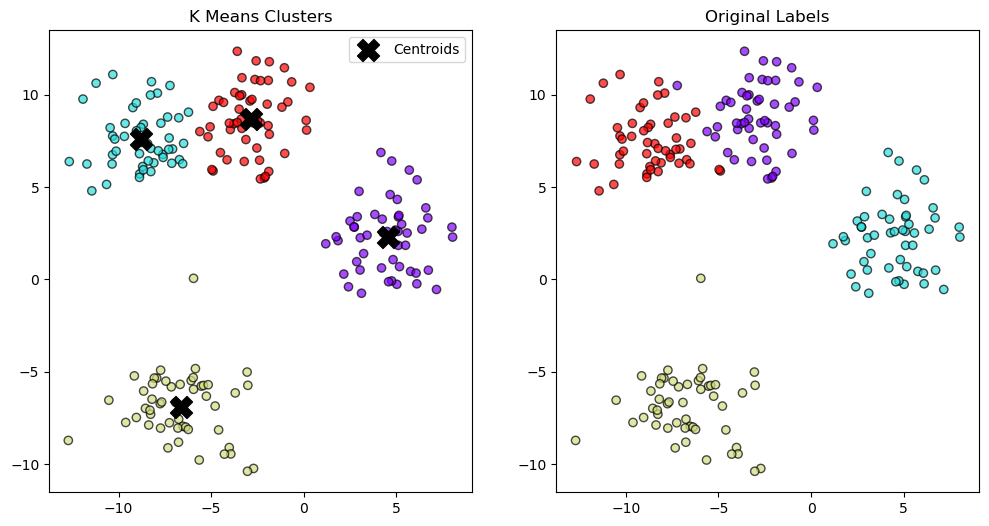

In [6]:
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
ax1.set_title('K Means Clusters')
ax1.scatter(data[0][:, 0], data[0][:, 1], c=pred, cmap='rainbow', edgecolor='k', alpha=0.7)
ax1.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            s=250, c='black', marker='X', label='Centroids')
ax1.legend()

ax2.set_title("Original Labels")
ax2.scatter(data[0][:, 0], data[0][:, 1], c=data[1], cmap='rainbow', edgecolor='k', alpha=0.7)

## Evaluating Clustering Quality


### 1. **Inertia (Within-Cluster Sum of Squares)**

Inertia measures how tightly the data points are clustered around their assigned centroids. It is the sum of squared distances between each data point and its closest cluster center.

**Formula:**
$$
\text{Inertia} = \sum_{i=1}^{n} \min_{\mu_j \in C} \|x_i - \mu_j\|^2
$$

- $x_i$: data point  
- $\mu_j$: centroid of cluster \( j \)  
- $C$: set of all centroids  
- **Lower** inertia indicates **tighter** clusters.

> Note: Inertia alone doesn’t indicate if the clustering is "good" — it always decreases with more clusters.

---

### 2. **Silhouette Score**

The Silhouette Score evaluates how similar a point is to its own cluster (cohesion) compared to other clusters (separation). It ranges from **-1 to 1**:

- **+1**: well-matched to its own cluster, far from others  
- **0**: on the boundary  
- **-1**: may be assigned to the wrong cluster

**Formula for a single sample:**
$$
s = \frac{b - a}{\max(a, b)}
$$

Where:
- $ a$: mean intra-cluster distance (average distance to all other points in the same cluster)  
- $b$: mean nearest-cluster distance (smallest average distance to points in any other cluster)

The **mean silhouette score** over all samples gives an overall measure of clustering quality.

---

### 3. **Adjusted Rand Index (ARI)**

ARI is a **supervised** evaluation metric used when **true labels** are available (like from `make_blobs`). It compares the similarity between the predicted cluster assignments and the ground truth, adjusted for chance.

**Formula:**
$$
\text{ARI} = \frac{\text{RI} - \mathbb{E}[\text{RI}]}{\max(\text{RI}) - \mathbb{E}[\text{RI}]}
$$

Where:
- **RI**: Rand Index — a measure of agreement between two partitions  
- **$\mathbb{E}[\text{RI}]$**: expected RI due to random chance

- ARI ranges from **-1 to 1**:
  - **1**: perfect match
  - **0**: random labeling
  - **<0**: worse than random

---

Each of these metrics gives a different perspective:
- Use **inertia** and **silhouette score** when true labels are **not available**.
- Use **ARI** when you **have ground truth labels** for evaluation.


In [7]:
from sklearn.metrics import silhouette_score, adjusted_rand_score

sil_score = silhouette_score(data[0], pred)
print(f"Silhouette Score: {sil_score:.3f}")

# Correctly compare true labels with predicted labels
ari_score = adjusted_rand_score(data[1], pred)
print(f"Adjusted Rand Index (ARI): {ari_score:.3f}")

print(f"Inertia: {kmeans.inertia_:.2f}")

Silhouette Score: 0.630
Adjusted Rand Index (ARI): 0.961
Inertia: 1155.05


# Great Job!

<div style="float:right;">
  <a href="https://github.com/MinooSdpr/Machine-Learning-101/blob/main/Session%2006/Session%2006%20-%20Matplotlib%20Concepts_1.ipynb"
     style="
       display:inline-block;
       padding:8px 20px;
       background-color:#414f6f;
       color:white;
       border-radius:12px;
       text-decoration:none;
       font-family:sans-serif;
       transition:background-color 0.3s ease;
     ">
    ▶️ Next
  </a>
</div>